In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.colors import TwoSlopeNorm
from adjustText import adjust_text

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import KFold, cross_val_score, permutation_test_score

from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
from matplotlib.cm import ScalarMappable

import warnings; warnings.filterwarnings('ignore')

In [2]:
sample_table = pd.read_csv("../data_processed/sample_table.csv", index_col=0)

color_pathway = {
    "mean_cbb_1":"#91cf60","mean_rtca_1":"#fc8d59","mean_wl_1":"#d73027",
    "mean_hp_1":"#91bfdb","mean_hphb_1":"#4575b4","mean_dchb_1":"#beeaf5",
}

sample_table = sample_table.drop(columns=["mean_C_metab", "mean_CFP", "mean_KOs", "mean_CFP_exclu"], errors="ignore")

pathways = ["mean_cbb_1","mean_rtca_1","mean_wl_1","mean_hp_1","mean_hphb_1","mean_dchb_1"]
pw_names = {"mean_cbb_1":"CBB","mean_rtca_1":"rTCA","mean_wl_1":"WL",
            "mean_hp_1":"3HP","mean_hphb_1":"HPHB","mean_dchb_1":"DC/HB"}


# PCA

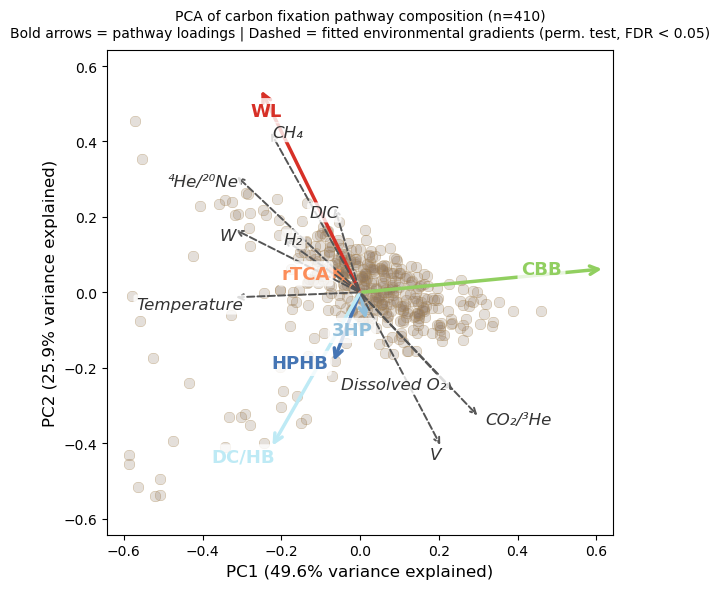

In [3]:
sub = sample_table[sample_table.surface_subsurface == "subsurface"].copy()

pw_data = sub[pathways].copy()
pw_data = pw_data[pw_data.sum(axis=1) > 0].dropna()
pw_rel = pw_data.div(pw_data.sum(axis=1), axis=0)
idx = pw_rel.index

pca = PCA(n_components=2)
scores = pca.fit_transform(pw_rel.values)
loadings = pca.components_
var_exp = pca.explained_variance_ratio_

env_candidates = {
    "temp": "Temperature",
    "do": "Dissolved O₂",
    "he4_ne20": "⁴He/²⁰Ne",
    "v": "V",
    "w": "W",
    "ch4_dry": "CH₄",
    "co2_3he": "CO₂/³He",
    "h2_dry": "H₂",
    "dic": "DIC",
}

log_vars = {"he4_ne20", "v", "w", "ch4_dry", "h2_dry"}

n_perm = 999
rng = np.random.default_rng(42)

env_results = []

for var, label in env_candidates.items():
    if var not in sub.columns:
        continue

    ev = sub.loc[idx, var].copy()

    if var in log_vars:
        ev = np.log10(ev.clip(lower=1e-10)).replace([np.inf, -np.inf], np.nan)

    mask = ev.notna()
    if mask.sum() < 50:
        continue

    x = ev[mask].values
    s1 = scores[mask.values, 0]
    s2 = scores[mask.values, 1]

    r1, _ = spearmanr(s1, x)
    r2, _ = spearmanr(s2, x)
    obs_stat = r1**2 + r2**2

    null_stats = np.empty(n_perm)
    for i in range(n_perm):
        x_perm = rng.permutation(x)
        rp1, _ = spearmanr(s1, x_perm)
        rp2, _ = spearmanr(s2, x_perm)
        null_stats[i] = rp1**2 + rp2**2

    p_perm = (np.sum(null_stats >= obs_stat) + 1) / (n_perm + 1)

    env_results.append({
        "var": var,
        "label": label,
        "r1": r1,
        "r2": r2,
        "stat": obs_stat,
        "p_perm": p_perm
    })

env_vecs = {}

if len(env_results) > 0:
    _, qvals, _, _ = multipletests(
        [x["p_perm"] for x in env_results],
        alpha=0.05,
        method="fdr_bh"
    )

    for res, q in zip(env_results, qvals):
        if q < 0.05:
            env_vecs[res["var"]] = (
                res["r1"],
                res["r2"],
                res["stat"],
                res["label"],
                res["p_perm"],
                q
            )

lim = np.percentile(np.abs(scores), 97) * 1.6
arrow_r = lim * 0.72

load_norms = np.sqrt(loadings[0]**2 + loadings[1]**2)
pw_scale = 1.35 * arrow_r / load_norms.max()

env_scale = 1.35 * arrow_r * 0.78 / max(np.sqrt(r1**2 + r2**2) for r1, r2, _, _, _, _ in env_vecs.values()) if env_vecs else 1.0

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    scores[:, 0], scores[:, 1],
    color="#89705a39", s=60,
    linewidths=0.2, edgecolors="#ad8b56ff", zorder=2
)

texts = []

for k, pw in enumerate(pathways):

    lx = loadings[0, k] * pw_scale
    ly = loadings[1, k] * pw_scale

    ax.annotate(
        "", xy=(lx, ly), xytext=(0, 0),
        arrowprops=dict(
            arrowstyle="->",
            color=color_pathway[pw],
            lw=2.5,
            mutation_scale=15
        )
    )

    t = ax.text(
        lx, ly, pw_names[pw],
        color=color_pathway[pw],
        fontsize=13,
        fontweight="bold",
        ha="center",
        va="center",
        zorder=6,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8)
    )
    texts.append(t)

for var, (r1, r2, stat, label, p_perm, q) in env_vecs.items():
    ex = r1 * env_scale
    ey = r2 * env_scale

    ax.annotate(
        "", xy=(ex, ey), xytext=(0, 0),
        arrowprops=dict(
            arrowstyle="->",
            color="#555555",
            lw=1.4,
            linestyle="dashed",
            mutation_scale=10
        )
    )

    t = ax.text(
        ex, ey, label,
        color="#333333",
        fontsize=12,
        style="italic",
        ha="center",
        va="center",
        zorder=6,
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8)
    )
    texts.append(t)

adjust_text(texts, ax=ax, lim=500, expand=(1.2, 1.2), force_text=(0.2, 0.2))

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel(f"PC1 ({var_exp[0] * 100:.1f}% variance explained)", fontsize=12)
ax.set_ylabel(f"PC2 ({var_exp[1] * 100:.1f}% variance explained)", fontsize=12)
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.tick_params(labelsize=10)

ax.set_title(
    f"PCA of carbon fixation pathway composition (n={len(idx)})\n"
    "Bold arrows = pathway loadings | Dashed = fitted environmental gradients (perm. test, FDR < 0.05)",
    fontsize=10,
    pad=10
)

plt.tight_layout()
plt.savefig("../outputs/fig_pca_biplot.svg", bbox_inches="tight", transparent=True)
plt.show()

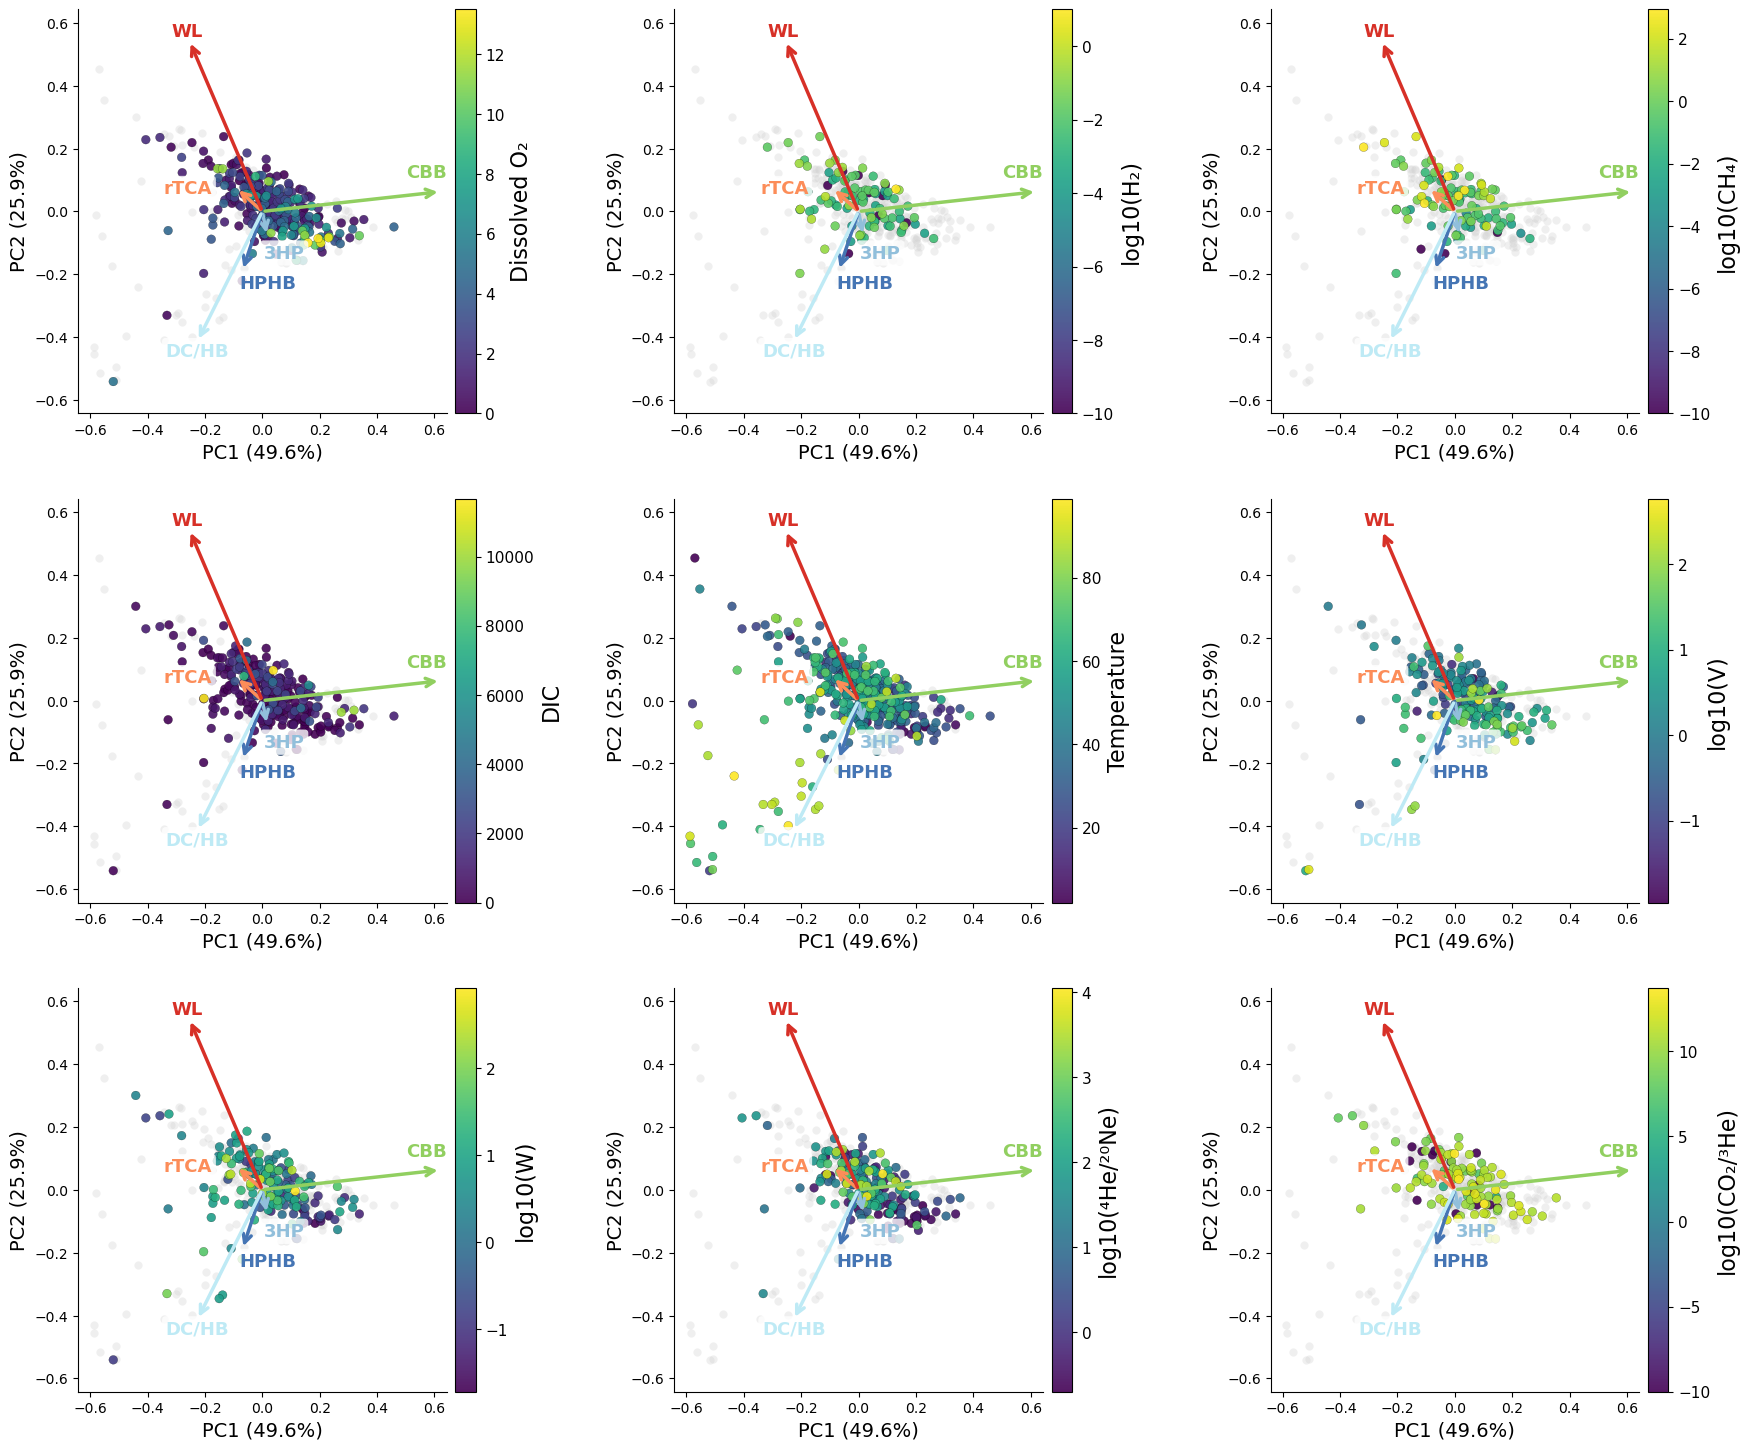

In [4]:
log_vars = log_vars | {"co2_3he"}

manual_offsets = {
    "mean_cbb_1":   (-0.05, 0.06),
    "mean_hp_1":    (0.06, -0.055),
    "mean_hphb_1":  (0.09, -0.04),
    "mean_dchb_1":  (0.00, -0.03),
    "mean_wl_1":    (-0.01, 0.03),
    "mean_rtca_1":  (-0.17, 0.00),
}

ordered_vars = [
    "do", "h2_dry", "ch4_dry",
    "dic", "temp", "v",
    "w", "he4_ne20", "co2_3he"
]
ordered_vars = [v for v in ordered_vars if v in env_candidates and v in sub.columns]

n = len(ordered_vars)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()

for i, var in enumerate(ordered_vars):
    ax = axes[i]
    label = env_candidates[var]

    ev = sub.loc[idx, var].copy()

    if var in log_vars:
        ev = np.log10(ev.clip(lower=1e-10)).replace([np.inf, -np.inf], np.nan)
        cbar_label = f"log10({label})"
    else:
        cbar_label = label

    mask = ev.notna()
    if mask.sum() < 50:
        ax.set_visible(False)
        continue

    if (~mask).sum() > 0:
        ax.scatter(
            scores[~mask.values, 0],
            scores[~mask.values, 1],
            color="lightgray",
            alpha=0.35,
            s=35,
            linewidths=0,
            zorder=1
        )

    order = np.argsort(ev[mask].values)

    x = scores[mask.values, 0][order]
    y = scores[mask.values, 1][order]
    c = ev[mask].values[order]

    sc = ax.scatter(
        x, y,
        c=c,
        cmap="viridis",
        s=40,
        alpha=0.9,
        linewidths=0.15,
        edgecolors="black",
        zorder=2
    )

    for k, pw in enumerate(pathways):
        lx = loadings[0, k] * pw_scale
        ly = loadings[1, k] * pw_scale

        ax.annotate(
            "",
            xy=(lx, ly),
            xytext=(0, 0),
            arrowprops=dict(
                arrowstyle="->",
                color=color_pathway[pw],
                lw=2.5,
                mutation_scale=15
            )
        )

        dx, dy = manual_offsets.get(pw, (0, 0))

        ax.text(
            lx + dx,
            ly + dy,
            pw_names[pw],
            color=color_pathway[pw],
            fontsize=13,
            fontweight="bold",
            ha="center",
            va="center",
            zorder=6,
            bbox=dict(
                boxstyle="round,pad=0.2",
                fc="white",
                ec="none",
                alpha=0.8
            )
        )

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)", fontsize=14)
    ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)", fontsize=14)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=10)

    cbar = plt.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label(cbar_label, fontsize=16)
    cbar.ax.tick_params(labelsize=11)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(pad=2.5, w_pad=3, h_pad=2.5)
plt.savefig("../outputs/pca_env_grid.png", dpi=300, transparent=True)
plt.show()

In [5]:
rows = []
for var, label in env_candidates.items():
    if var not in sub.columns: continue
    ev = sub.loc[idx, var].copy()
    if var in log_vars:
        ev = np.log10(ev.clip(lower=1e-10)).replace([np.inf,-np.inf], np.nan)
    mask = ev.notna()
    n = mask.sum()
    if n < 50: continue
    r1, p1 = spearmanr(scores[mask.values,0], ev[mask].values)
    r2, p2 = spearmanr(scores[mask.values,1], ev[mask].values)
    rows.append({"Variable": label, "n": n,
                 "\u03c1 PC1": round(r1, 3), "p PC1": round(p1, 4),
                 "\u03c1 PC2": round(r2, 3), "p PC2": round(p2, 4),
                 "R\u00b2 total": round(r1**2 + r2**2, 3)})

metrics_df = (pd.DataFrame(rows)
              .sort_values("R\u00b2 total", ascending=False)
              .reset_index(drop=True))

display(metrics_df.style
        .format({"\u03c1 PC1": "{:+.3f}", "\u03c1 PC2": "{:+.3f}",
                 "p PC1": "{:.4f}", "p PC2": "{:.4f}",
                 "R\u00b2 total": "{:.3f}"})
        .background_gradient(subset=["R\u00b2 total"], cmap="YlOrRd")
        .set_caption(f"Spearman correlations of environmental variables with PC1 & PC2  "
                     f"(PCA on relative pathway abundances, n={len(idx)} samples)"))

,Variable,n,ρ PC1,p PC1,ρ PC2,p PC2,R² total
0,CH₄,102,-0.250,0.0112,+0.468,0.0000,0.281
1,V,185,+0.225,0.0021,-0.447,0.0000,0.251
2,CO₂/³He,115,+0.330,0.0003,-0.360,0.0001,0.238
3,⁴He/²⁰Ne,194,-0.345,0.0000,+0.340,0.0000,0.235
4,W,168,-0.350,0.0000,+0.184,0.0171,0.157
5,Dissolved O₂,283,+0.261,0.0000,-0.289,0.0000,0.152
6,Temperature,390,-0.350,0.0000,-0.014,0.7774,0.123
7,H₂,100,-0.217,0.0303,+0.158,0.1156,0.072
8,DIC,287,-0.072,0.2246,+0.252,0.0000,0.068


# Spearman correlations between CFPs and env variables

In [6]:
log_vars_hm = {
    "sal","spc","na","k","cl","so4","mg","ca","alk_tot",
    "ch4_dry","he4_ne20","v","w","mn","fe",
    "la","gd","ho","er","eu","h2_dry","co2_dry",
}
PW_ORDER = ["mean_cbb_1","mean_hp_1","mean_hphb_1","mean_dchb_1","mean_wl_1","mean_rtca_1"]

In [7]:
def compute_correlations(groups, min_n=20):
    col_order = [(c, l) for items in groups.values()
                 for c, l in items if c in sub.columns]
    cols, labels = [c for c,_ in col_order], [l for _,l in col_order]
    env_df = sub[cols].copy()
    for col in cols:
        if col in log_vars_hm:
            env_df[col] = np.log10(pd.to_numeric(env_df[col], errors="coerce").clip(lower=1e-10))
            env_df[col] = env_df[col].replace([np.inf,-np.inf], np.nan)
    rows = []
    for pw in PW_ORDER:
        y = sub[pw]
        for col in cols:
            mask = y.notna() & env_df[col].notna()
            n = mask.sum()
            if n >= min_n:
                rho, p = spearmanr(y[mask], env_df[col][mask])
                rows.append({"pathway":pw,"env":col,"rho":rho,"pval":p,"n":n})
            else:
                rows.append({"pathway":pw,"env":col,"rho":np.nan,"pval":np.nan,"n":n})
    df_c = pd.DataFrame(rows)
    valid = df_c["pval"].notna()
    _, padj, _, _ = multipletests(df_c.loc[valid,"pval"], method="fdr_bh")
    df_c.loc[valid,"pval_fdr"] = padj
    rho_mat  = df_c.pivot(index="pathway",columns="env",values="rho").reindex(columns=cols, index=PW_ORDER)
    pval_mat = df_c.pivot(index="pathway",columns="env",values="pval_fdr").reindex(columns=cols, index=PW_ORDER)
    return (rho_mat, pval_mat, cols, labels, PW_ORDER)


def make_heatmap_squares(groups, title, filename, cell_size_in=0.55, min_n=20):
    rho_plot, pval_plot, cols, labels, row_order = compute_correlations(groups, min_n=min_n)
    cat_spans, col_idx = [], 0
    for cat, items in groups.items():
        n = sum(1 for c, _ in items if c in sub.columns)
        if n > 0:
            cat_spans.append((cat, col_idx, col_idx + n)); col_idx += n

    n_cols, n_rows = len(cols), len(row_order)

    hm_w_in  = cell_size_in * n_cols
    hm_h_in  = cell_size_in * n_rows

    left_in  = 0.65   # y-tick labels
    right_in = 1.20   # colorbar + size legend
    top_in   = 0.55   # title
    bar_in   = 0.45   # category bar (tall enough for 2-line text)
    gap_in   = 0.08   # gap bar ↔ heatmap
    bot_in   = 1.10   # x-tick labels

    fig_w = left_in + hm_w_in + right_in
    fig_h = bot_in  + hm_h_in + gap_in + bar_in + top_in

    def to_frac(x, y, w, h):
        return [x/fig_w, y/fig_h, w/fig_w, h/fig_h]

    fig = plt.figure(figsize=(fig_w, fig_h))
    ax_hm  = fig.add_axes(to_frac(left_in, bot_in, hm_w_in, hm_h_in))
    ax_cat = fig.add_axes(to_frac(left_in, bot_in + hm_h_in + gap_in, hm_w_in, bar_in))

    cbar_w_in   = 0.15
    cbar_h_in   = min(hm_h_in * 0.45, 1.8)
    cbar_pad_in = 0.18
    cbar_x_in   = left_in + hm_w_in + cbar_pad_in
    cbar_y_in   = bot_in + (hm_h_in - cbar_h_in) / 2
    cax = fig.add_axes(to_frac(cbar_x_in, cbar_y_in, cbar_w_in, cbar_h_in))

    leg_size = 0.55
    ax_leg = fig.add_axes(to_frac(
        cbar_x_in + cbar_w_in + 0.18,
        bot_in + (hm_h_in - leg_size * 3) / 2,
        leg_size, leg_size * 3))

    ax_cat.set_xlim(-0.5, n_cols - 0.5)
    ax_cat.set_ylim(0, 1)
    ax_cat.axis("off")
    for cat, start, end in cat_spans:
        ax_cat.add_patch(plt.Rectangle(
            (start - 0.47, 0.05), end - start - 0.06, 0.90,
            facecolor="#f3f3f3", edgecolor="none", zorder=2))
        ax_cat.text((start + end - 1) / 2, 0.52, cat,
                    ha="center", va="center",
                    fontsize=12, color="#000000",
                    linespacing=1.3, zorder=3)

    cmap = plt.cm.RdBu_r
    norm = TwoSlopeNorm(vmin=-0.6, vcenter=0, vmax=0.6)

    ax_hm.set_facecolor("white")
    ax_hm.set_xlim(-0.5, n_cols - 0.5)
    ax_hm.set_ylim(n_rows - 0.5, -0.5)
    ax_hm.set_aspect("equal")

    for y in np.arange(-0.5, n_rows + 0.5):
        ax_hm.axhline(y, color="#dedede", lw=0.5, zorder=1)
    for x in np.arange(-0.5, n_cols + 0.5):
        ax_hm.axvline(x, color="#dedede", lw=0.5, zorder=1)
    for _, start, _ in cat_spans[1:]:
        ax_hm.axvline(start - 0.5, color="#aaaaaa", lw=1.0, zorder=2)

    for i in range(n_rows):
        for j in range(n_cols):
            rv = rho_plot.values[i, j]
            pv = pval_plot.values[i, j]
            if np.isnan(rv):
                s = 0.425
                ax_hm.add_patch(plt.Rectangle([j-s, i-s], 2*s, 2*s,
                    facecolor="#c8c8c8", edgecolor="none", zorder=3))
            else:
                s = 0.0 if (np.isnan(pv) or pv >= 0.05) else 0.425 if pv < 0.001 else 0.300 if pv < 0.01 else 0.175
                if s > 0:
                    ax_hm.add_patch(plt.Rectangle([j-s, i-s], 2*s, 2*s,
                        facecolor=cmap(norm(rv)), edgecolor="none", zorder=3))

    ax_hm.set_xticks(range(n_cols))
    ax_hm.set_xticklabels(labels, rotation=90, fontsize=12)
    ax_hm.tick_params(left=False, bottom=False)
    ax_hm.set_yticks(range(n_rows))
    ax_hm.set_yticklabels([pw_names[p] for p in row_order], fontsize=12, color="black")
    for spine in ax_hm.spines.values():
        spine.set_linewidth(0.5)

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=cax)
    cbar.set_label("Spearman ρ", fontsize=12)
    cbar.ax.tick_params(labelsize=7.5)
    cbar.outline.set_linewidth(0.5)

    legend_items = [(0.425, "q < 0.001"), (0.300, "q < 0.01"), (0.175, "q < 0.05")]
    ax_leg.set_xlim(-0.5, 0.5)
    ax_leg.set_ylim(-0.5, len(legend_items) - 0.5)
    ax_leg.set_aspect("equal")
    ax_leg.axis("off")
    for k, (s, lbl) in enumerate(legend_items):
        ax_leg.add_patch(plt.Rectangle([-s, k-s], 2*s, 2*s,
            facecolor="#888888", edgecolor="none"))
        ax_leg.text(0, k + s + 0.08, lbl,
            ha="center", va="bottom", fontsize=6.5, color="#444444")

    title_y = (bot_in + hm_h_in + gap_in + bar_in) / fig_h + 0.01
    fig.text(0.5, title_y,
             title + f"\n(n = {len(sub)}; square size = FDR-BH q; "
             "color = Spearman ρ; grey = n < " + str(min_n) + "; log₁₀ applied to right-skewed variables)",
             ha="center", va="bottom", fontsize=8.5, color="#333333")

    plt.savefig("../outputs/" + filename + ".svg", bbox_inches="tight", transparent=True)
    plt.show()


In [8]:
_sub_check = sample_table[sample_table.surface_subsurface == "subsurface"].copy()

_included = {
    "temp","ph","elevation","latitude","longitude",
    "do","orp","o2_dis","o2_dry","s_dry",
    "h2_dry","h2_dis","ch4_dry","ch4_dis","co2_dry","co2_dis","co_dry",
    "he4_ne20","r_ra","rc_ra","he4","he_dry","he_dis",
    "ar_dry","ar_dis","n2_dry","n2_dis","D_w","d18O_w","d13DIC",
    "co2_3he","co2_4he","co2_ar","co2_ch4","co2_he","d13CO2_dry",
    "sal","spc","cl","br","so4","alk_tot","dic","na","k","ca","mg",
    "li","nh4","no3","po4","sio2","toc",
    "v","w","fe","fe2","mn","co","ni","cu","as","mo","cr","al",
    "ba","sr","rb","cs","u","tl","pb","zn","cd","ag","be","bo","ga","zr",
    "y","nb","ti","se","re","ta",
    "la","ce","pr","nd","sm","eu","gd","dy","ho","er","tm","yb","th",
}
_numeric = _sub_check.select_dtypes(include="number").columns
_excluded = []
for col in _numeric:
    if col in _included or col in {"mean_cbb_1","mean_hp_1","mean_hphb_1","mean_dchb_1","mean_wl_1","mean_rtca_1","mean_CFP_key_1"}:
        continue
    n = _sub_check[col].notna().sum()
    _excluded.append((col, n))

_excluded.sort(key=lambda x: -x[1])

for col, n in _excluded:
    print(f"  {col:<30s}  n={n}")

  readcount                       n=412
  map_id                          n=385
  source_id                       n=385
  t_int_id                        n=378
  b_int_id                        n=378
  t_age                           n=378
  b_age                           n=378
  lat_d                           n=373
  long_d                          n=373
  dist_to_sample                  n=373
  major_sum                       n=373
  sio2_d                          n=373
  tio2_d                          n=373
  al2o3_d                         n=373
  cao_d                           n=373
  na2o_d                          n=373
  k2o_d                           n=373
  mno_d                           n=371
  p2o5_d                          n=369
  mgo_d                           n=359
  sr_d                            n=352
  zr_d                            n=348
  y_d                             n=346
  nb_d                            n=345
  ba_d                            n=341


In [9]:
GROUPS_SUPPL = {
    "Environmental": [
        ("temp","Temperature"),("ph","pH"),("elevation","Elevation"),
        ("latitude","Latitude"),("longitude","Longitude"),
    ],
    "Redox & gases": [
        ("do","DO"),("orp","ORP"),
        ("o2_dis","O₂ (dis)"),("o2_dry","O₂ (dry)"),("s_dry","S (dry)"),
        ("h2_dry","H₂ (dry)"),("h2_dis","H₂ (dis)"),
        ("ch4_dry","CH₄ (dry)"),("ch4_dis","CH₄ (dis)"),
        ("co2_dry","CO₂ (dry)"),("co2_dis","CO₂ (dis)"),("co_dry","CO (dry)"),
    ],
    "Subsurface\ntracers": [
        ("he4_ne20","⁴He/²⁰Ne"),("r_ra","R/Ra"),("rc_ra","Rc/Ra"),
        ("he4","⁴He"),("he_dry","He (dry)"),("he_dis","He (dis)"),
        ("ar_dry","Ar (dry)"),("ar_dis","Ar (dis)"),
        ("n2_dry","N₂ (dry)"),("n2_dis","N₂ (dis)"),
        ("D_w","δD water"),("d18O_w","δ¹⁸O water"),("d13DIC","δ¹³C DIC"),
    ],
    "Gas ratios &\nisotopes": [
        ("co2_3he","CO₂/³He"),("co2_4he","CO₂/⁴He"),("co2_ar","CO₂/Ar"),
        ("co2_ch4","CO₂/CH₄"),("co2_he","CO₂/He"),("d13CO2_dry","δ¹³C CO₂"),
    ],
    "Major ions": [
        ("sal","Salinity"),("spc","Spec. cond."),
        ("cl","Cl⁻"),("br","Br⁻"),("so4","SO₄²⁻"),("alk_tot","Alkalinity"),
        ("dic","DIC"),("na","Na⁺"),("k","K⁺"),("ca","Ca²⁺"),("mg","Mg²⁺"),
        ("li","Li"),("nh4","NH₄⁺"),("no3","NO₃⁻"),("po4","PO₄³⁻"),
        ("sio2","SiO₂"),("toc","TOC"),
    ],
    "Redox metals": [
        ("v","V"),("w","W"),("fe","Fe"),("fe2","Fe²⁺"),("mn","Mn"),
        ("co","Co"),("ni","Ni"),("cu","Cu"),("as","As"),("mo","Mo"),("cr","Cr"),("al","Al"),
    ],
    "Trace elements": [
        ("ba","Ba"),("sr","Sr"),("rb","Rb"),("cs","Cs"),("u","U"),
        ("tl","Tl"),("pb","Pb"),("zn","Zn"),("cd","Cd"),("ag","Ag"),
        ("be","Be"),("bo","B"),("ga","Ga"),("zr","Zr"),("y","Y"),
        ("nb","Nb"),("ti","Ti"),("se","Se"),("re","Re"),("ta","Ta"),
    ],
    "REE": [
        ("la","La"),("ce","Ce"),("pr","Pr"),("nd","Nd"),("sm","Sm"),
        ("eu","Eu"),("gd","Gd"),("dy","Dy"),("ho","Ho"),("er","Er"),
        ("tm","Tm"),("yb","Yb"),("th","Th"),
    ],
}


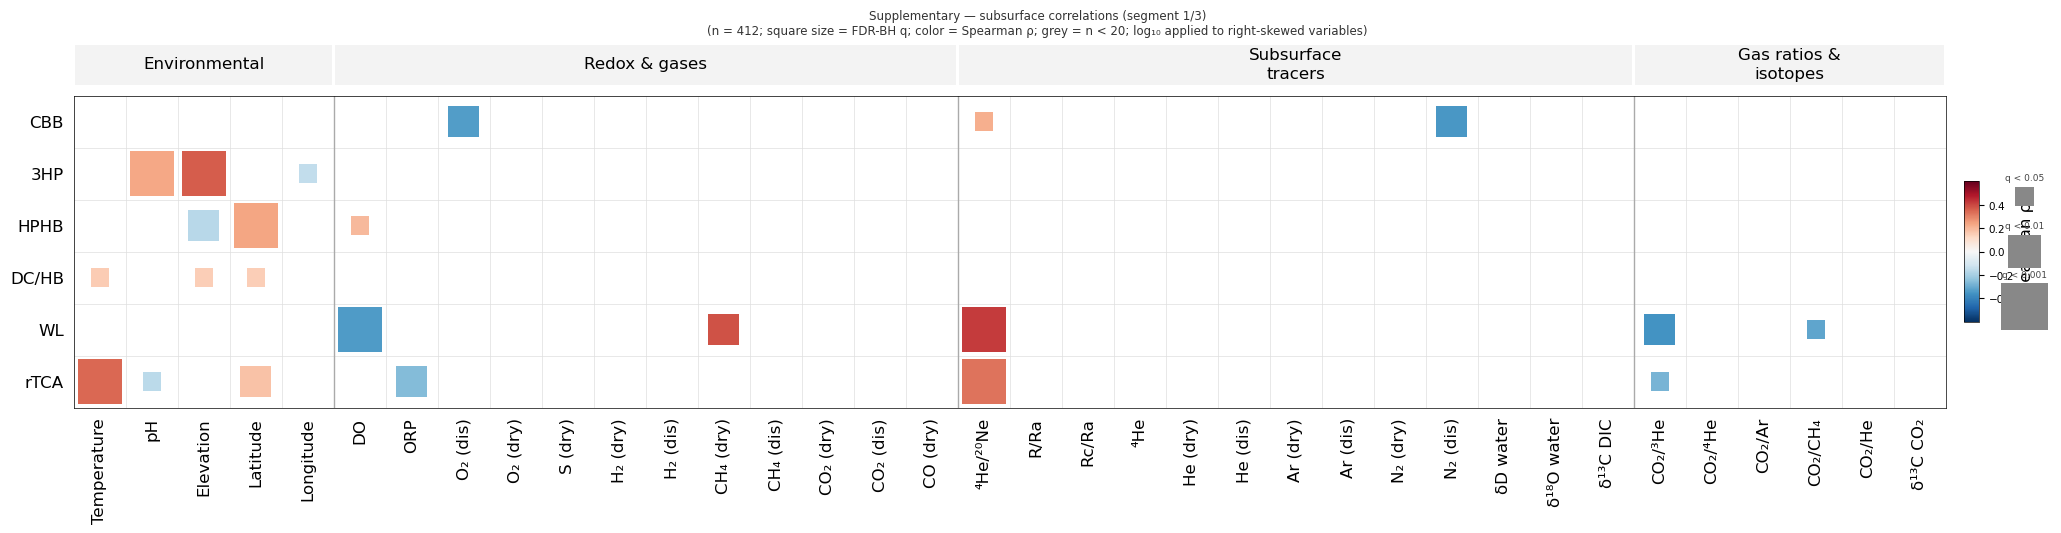

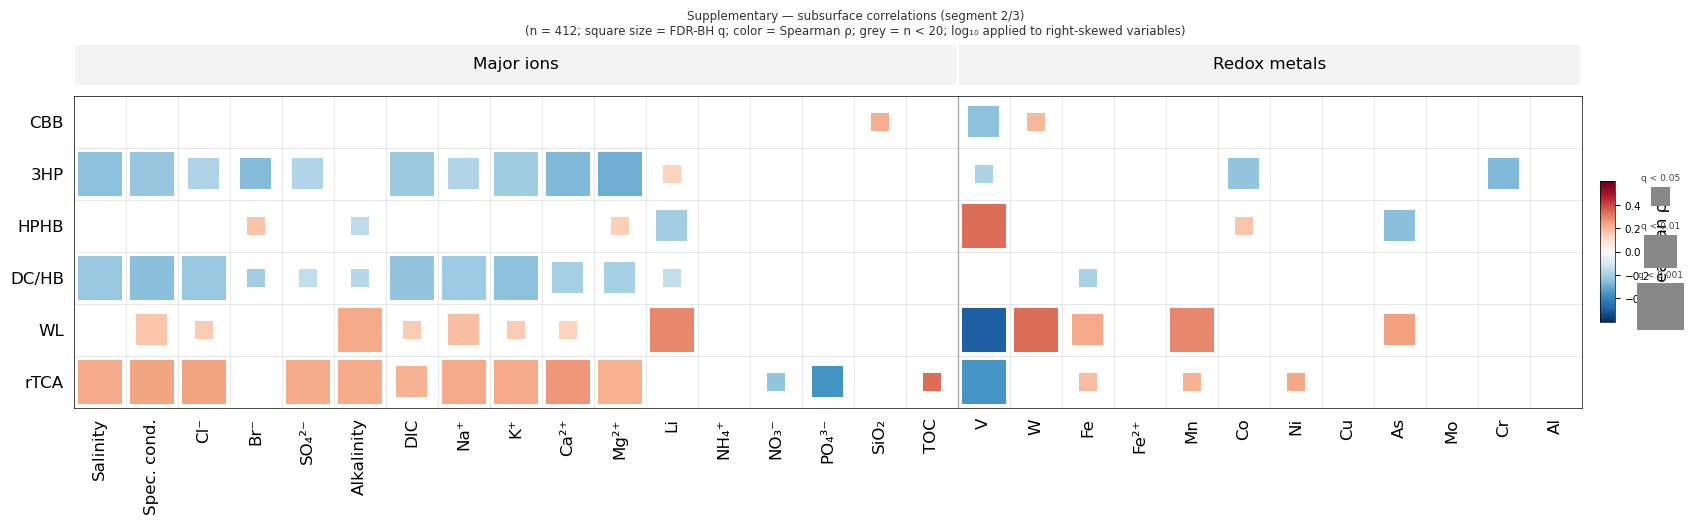

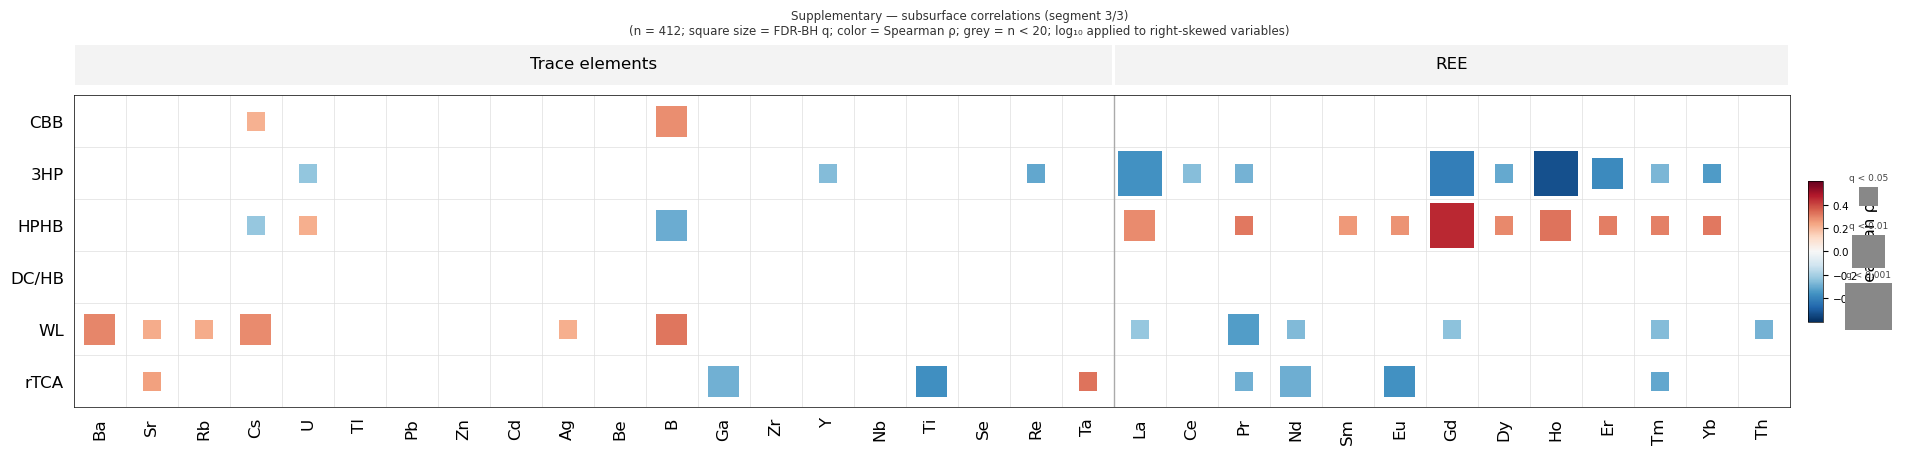

In [10]:

sub = sample_table[sample_table.surface_subsurface == "subsurface"].copy()

_orig_log_seg = log_vars_hm.copy()
log_vars_hm.update({
    "dic","br","li","nh4","no3","po4","sio2",
    "fe2","co","ni","cu","as","mo","cr","al",
    "co_dry","s_dry","ch4_dis","h2_dis","co2_dis",
    "co2_ar","co2_ch4","co2_he","co2_4he",
    "he4","he_dry","he_dis",
    "ba","sr","rb","cs","u","tl","pb","zn","cd","ag","be","bo","ga","zr",
    "y","nb","ti","se","re","ta",
    "ce","nd","sm","pr","tm","dy","yb","th",
    "r_ra","rc_ra","toc",
})

_keys = list(GROUPS_SUPPL)
GROUPS_SEG1 = {k: GROUPS_SUPPL[k] for k in _keys[:4]}
GROUPS_SEG2 = {k: GROUPS_SUPPL[k] for k in _keys[4:6]}
GROUPS_SEG3 = {k: GROUPS_SUPPL[k] for k in _keys[6:]}

for i, grp in enumerate([GROUPS_SEG1, GROUPS_SEG2, GROUPS_SEG3], start=1):
    make_heatmap_squares(
        grp,
        f"Supplementary — subsurface correlations (segment {i}/3)",
        f"heatmap_suppl_seg{i}",
        cell_size_in=0.52,
        min_n=20,
    )

log_vars_hm.clear(); log_vars_hm.update(_orig_log_seg)
sub = sample_table[sample_table.surface_subsurface == "subsurface"].copy()

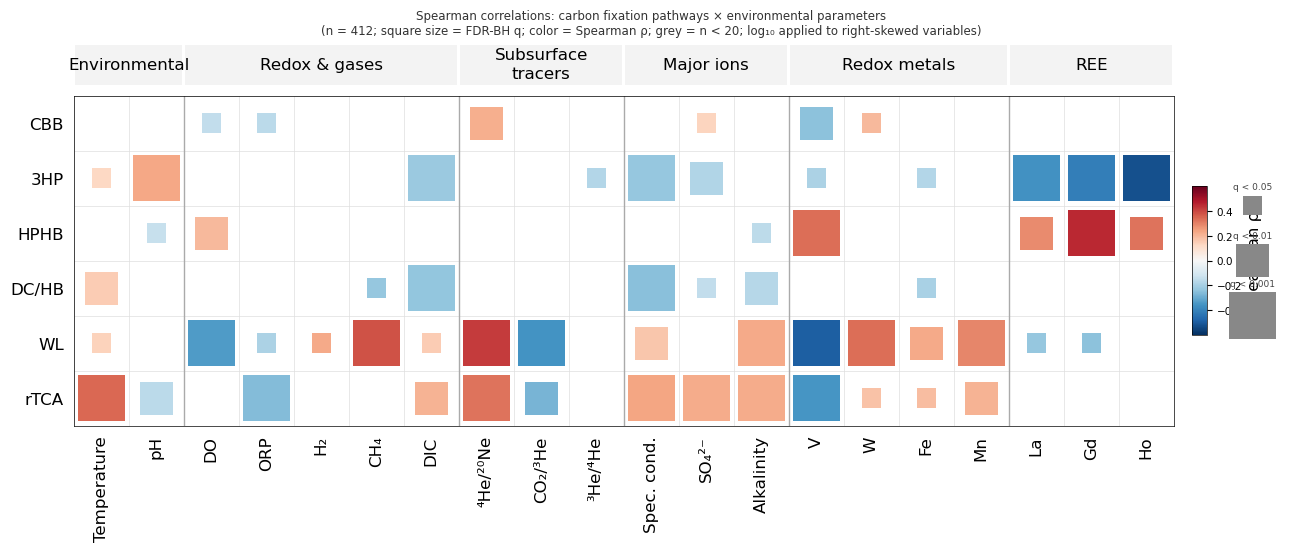

In [11]:
GROUPS_RELEVANT = {
    "Environmental": [
        ("temp", "Temperature"), ("ph", "pH")],
    "Redox & gases": [
        ("do", "DO"), ("orp", "ORP"), ("h2_dry", "H₂"), ("ch4_dry", "CH₄"), ("dic", "DIC")],
    "Subsurface\ntracers": [
        ("he4_ne20", "⁴He/²⁰Ne"), ("co2_3he", "CO₂/³He"), ("r_ra", "³He/⁴He")],
    "Major ions": [
        ("spc", "Spec. cond."), ("so4", "SO₄²⁻"), ("alk_tot", "Alkalinity")],
    "Redox metals": [
        ("v", "V"), ("w", "W"), ("fe", "Fe"), ("mn", "Mn")],
    "REE": [
        ("la", "La"), ("gd", "Gd"), ("ho", "Ho")],
}

make_heatmap_squares(
    GROUPS_RELEVANT,
    "Spearman correlations: carbon fixation pathways × environmental parameters",
    "heatmap_squares_minimal",
    cell_size_in=0.55,
)

# Exploration of surface datasets

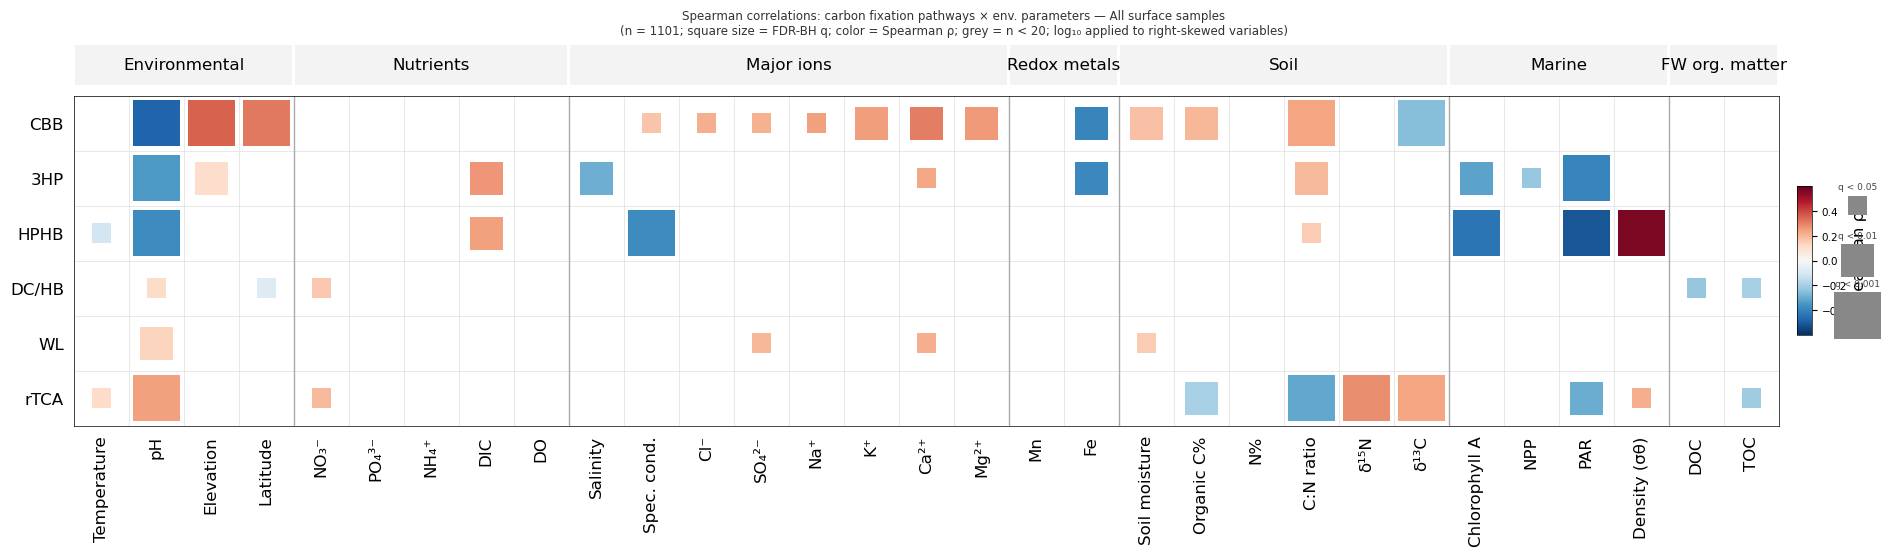

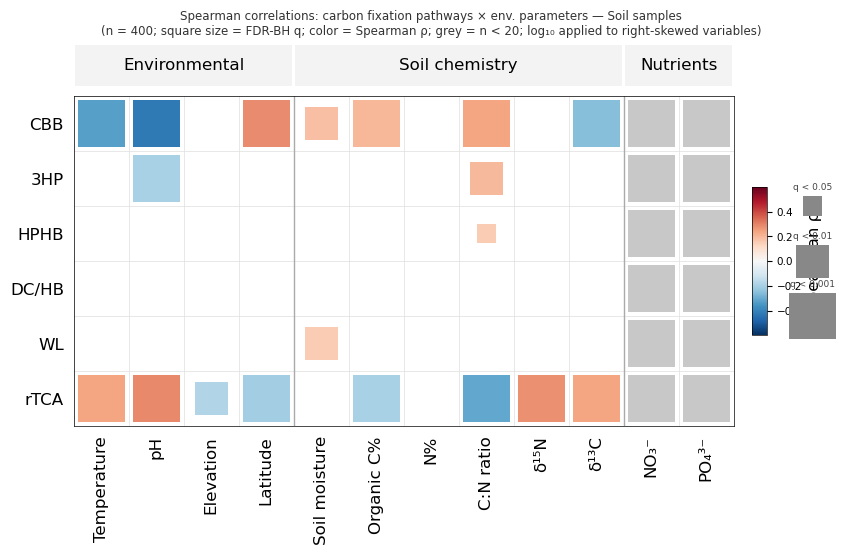

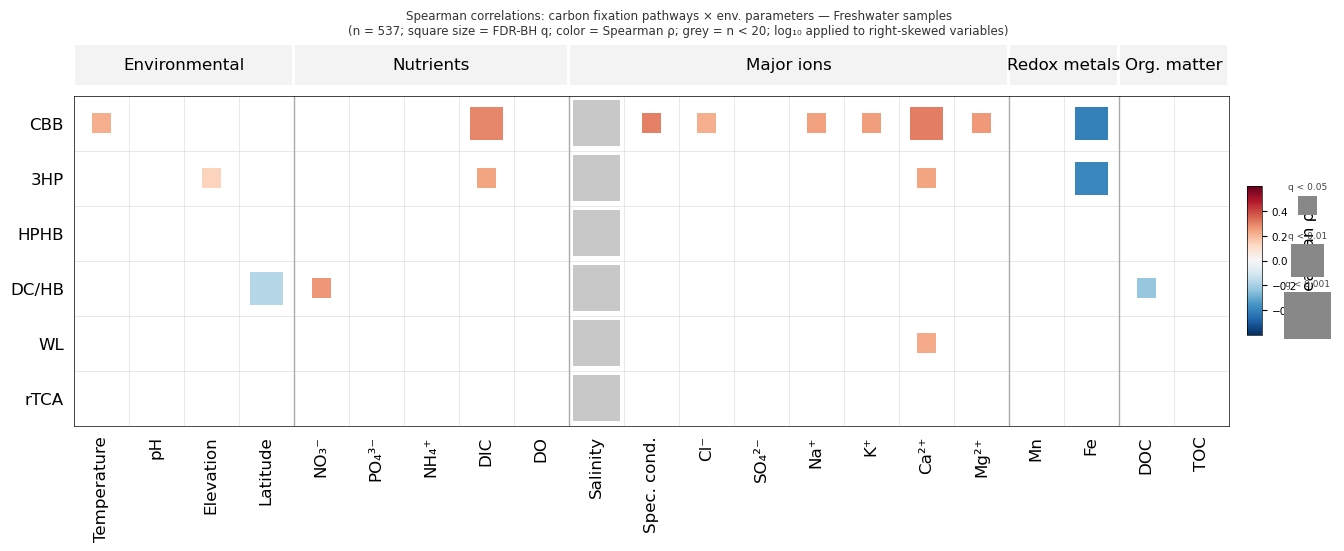

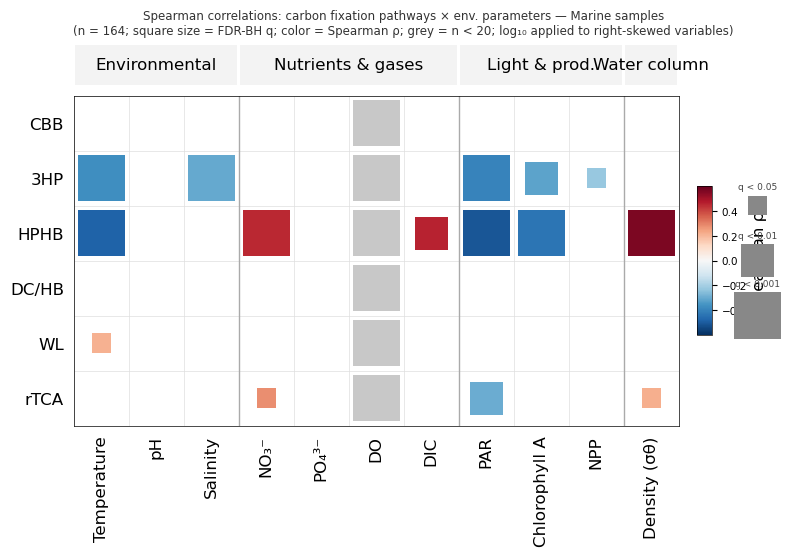

In [12]:
surface_samples = sample_table[sample_table.surface_subsurface == "surface"]

_orig_log = log_vars_hm.copy()
log_vars_hm.update({"no3", "po4", "nh4", "dic", "doc", "TOC", "soilMoisture", "Chlorophyll_A (mg/m**3)", "NPP_C* (mg/m**2/day)"})

sub = surface_samples.copy()

GROUPS_GLOBAL = {
    "Environmental": [
        ("temp","Temperature"), ("ph","pH"), ("elevation","Elevation"), ("latitude","Latitude")],
    "Nutrients": [
        ("no3","NO₃⁻"), ("po4","PO₄³⁻"), ("nh4","NH₄⁺"), ("dic","DIC"), ("do","DO")],
    "Major ions": [
        ("sal","Salinity"), ("spc","Spec. cond."), ("cl","Cl⁻"), ("so4","SO₄²⁻"),
        ("na","Na⁺"), ("k","K⁺"), ("ca","Ca²⁺"), ("mg","Mg²⁺")],
    "Redox metals": [("mn","Mn"), ("fe","Fe")],
    "Soil": [
        ("soilMoisture","Soil moisture"), ("organicCPercent","Organic C%"),
        ("nitrogenPercent","N%"), ("CNratio","C:N ratio"),
        ("d15N","δ¹⁵N"), ("organicd13C","δ¹³C")],
    "Marine": [
        ("Chlorophyll_A (mg/m**3)","Chlorophyll A"), ("NPP_C* (mg/m**2/day)","NPP"),
        ("PAR (mol quanta/m**2/day)","PAR"), ("sigma_theta","Density (σθ)")],
    "FW org. matter": [("doc","DOC"), ("TOC","TOC")],
}

make_heatmap_squares(
    GROUPS_GLOBAL,
    "Spearman correlations: carbon fixation pathways × env. parameters — All surface samples",
    "heatmap_surface_global",
)

GROUPS_SOIL = {
    "Environmental": [
        ("temp","Temperature"), ("ph","pH"), ("elevation","Elevation"), ("latitude","Latitude")],
    "Soil chemistry": [
        ("soilMoisture","Soil moisture"), ("organicCPercent","Organic C%"),
        ("nitrogenPercent","N%"), ("CNratio","C:N ratio"),
        ("d15N","δ¹⁵N"), ("organicd13C","δ¹³C")],
    "Nutrients": [("no3","NO₃⁻"), ("po4","PO₄³⁻")],
}
GROUPS_FRESHWATER = {
    "Environmental": [
        ("temp","Temperature"), ("ph","pH"), ("elevation","Elevation"), ("latitude","Latitude")],
    "Nutrients": [
        ("no3","NO₃⁻"), ("po4","PO₄³⁻"), ("nh4","NH₄⁺"), ("dic","DIC"), ("do","DO")],
    "Major ions": [
        ("sal","Salinity"), ("spc","Spec. cond."), ("cl","Cl⁻"), ("so4","SO₄²⁻"),
        ("na","Na⁺"), ("k","K⁺"), ("ca","Ca²⁺"), ("mg","Mg²⁺")],
    "Redox metals": [("mn","Mn"), ("fe","Fe")],
    "Org. matter":  [("doc","DOC"), ("TOC","TOC")],
}
GROUPS_MARINE = {
    "Environmental":     [("temp","Temperature"), ("ph","pH"), ("sal","Salinity")],
    "Nutrients & gases": [("no3","NO₃⁻"), ("po4","PO₄³⁻"), ("do","DO"), ("dic","DIC")],
    "Light & prod.":     [("PAR (mol quanta/m**2/day)","PAR"),
                          ("Chlorophyll_A (mg/m**3)","Chlorophyll A"),
                          ("NPP_C* (mg/m**2/day)","NPP")],
    "Water column":      [("sigma_theta","Density (σθ)")],
}

for label, df_sub, groups in [
    ("Soil",       surface_samples[surface_samples.sample_group == "soil"],         GROUPS_SOIL),
    ("Freshwater", surface_samples[surface_samples.sample_group == "freshwater"],   GROUPS_FRESHWATER),
    ("Marine",     surface_samples[surface_samples.sample_group == "marine_water"], GROUPS_MARINE),
]:
    sub = df_sub.copy()
    make_heatmap_squares(
        groups,
        f"Spearman correlations: carbon fixation pathways × env. parameters — {label} samples",
        f"heatmap_surface_{label.lower()}",
    )

log_vars_hm.clear(); log_vars_hm.update(_orig_log)
sub = sample_table[sample_table.surface_subsurface == "subsurface"].copy()


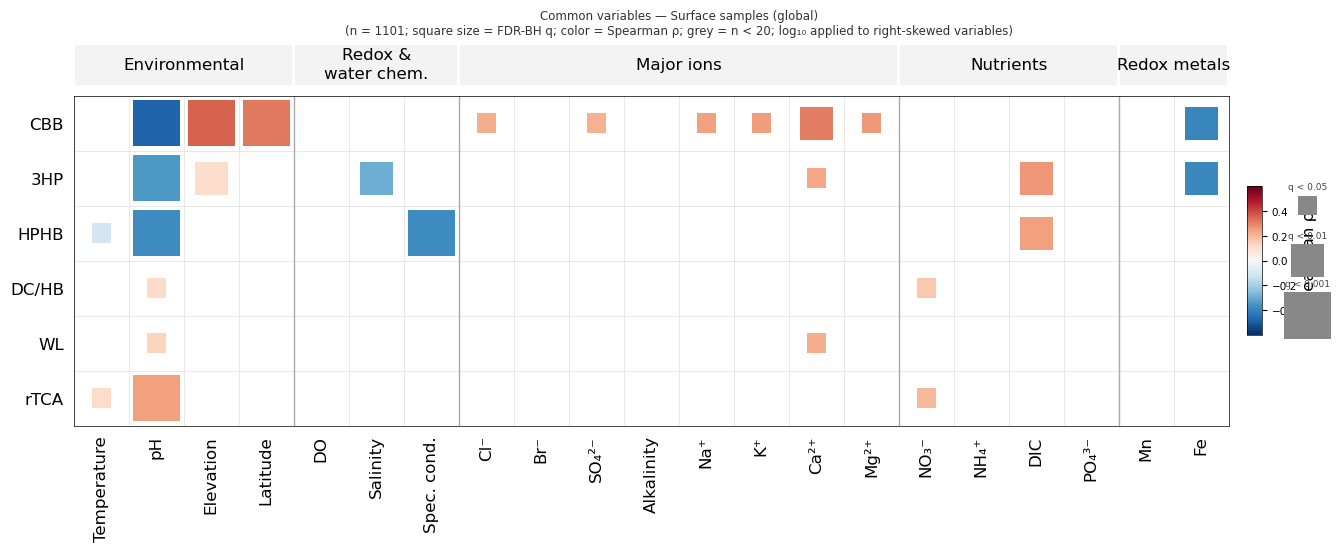

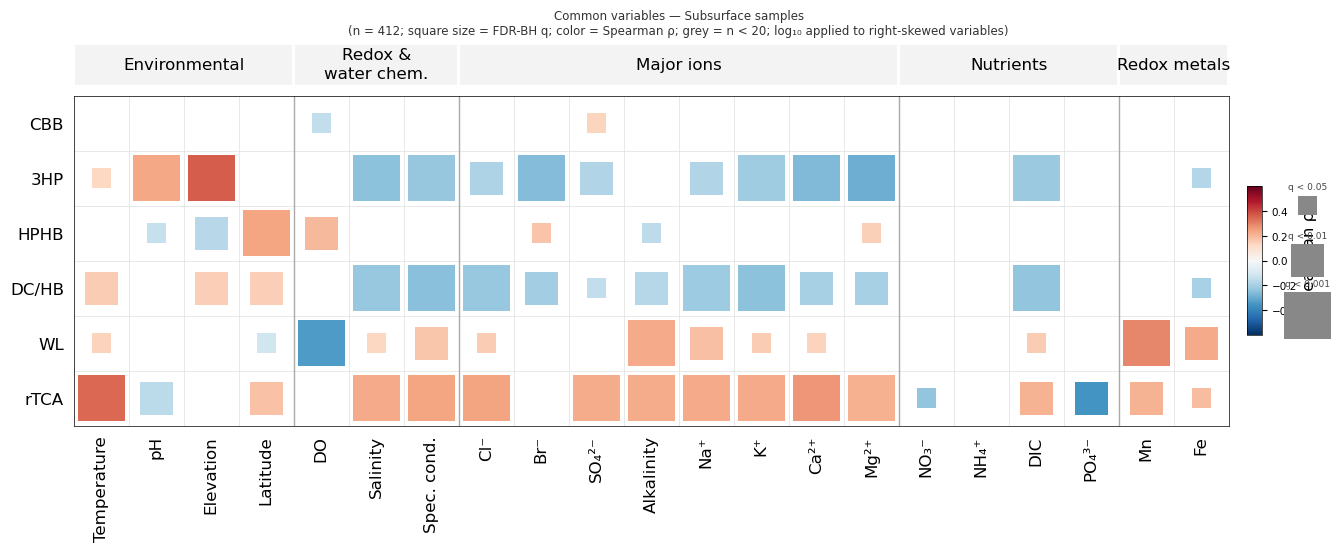

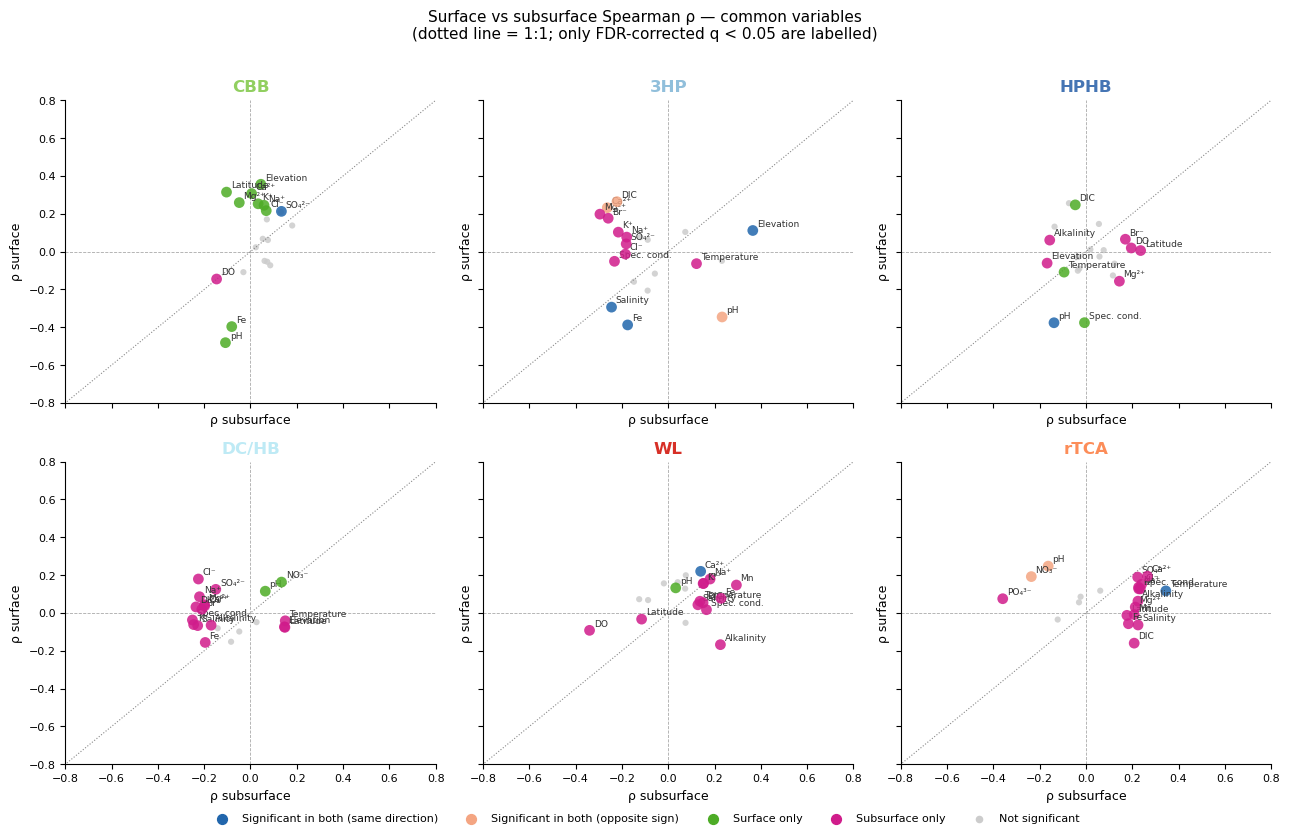


=== Correlations significant in BOTH datasets (same direction) ===
Pathway  Variable               ρ surf     ρ sub
----------------------------------------------
CBB      SO₄²⁻                  +0.213    +0.134
3HP      Elevation              +0.112    +0.365
3HP      Salinity               -0.294    -0.245
3HP      Fe                     -0.388    -0.175
HPHB     pH                     -0.376    -0.138
WL       Ca²⁺                   +0.220    +0.140
rTCA     Temperature            +0.117    +0.345

=== Discrepant (significant in both, OPPOSITE sign) ===
Pathway  Variable               ρ surf     ρ sub
----------------------------------------------
3HP      pH                     -0.346    +0.233
3HP      Ca²⁺                   +0.232    -0.263
3HP      DIC                    +0.264    -0.221
rTCA     pH                     +0.248    -0.163
rTCA     NO₃⁻                   +0.192    -0.236

=== Surface-only significant correlations ===
Pathway  Variable               ρ surf    q surf

In [13]:
GROUPS_COMMON = {
    "Environmental": [
        ("temp",      "Temperature"),
        ("ph",        "pH"),
        ("elevation", "Elevation"),
        ("latitude",  "Latitude"),
    ],
    "Redox &\nwater chem.": [
        ("do",  "DO"),
        ("sal", "Salinity"),
        ("spc", "Spec. cond."),
    ],
    "Major ions": [
        ("cl",      "Cl\u207b"),
        ("br",      "Br\u207b"),
        ("so4",     "SO\u2084\u00b2\u207b"),
        ("alk_tot", "Alkalinity"),
        ("na",      "Na\u207a"),
        ("k",       "K\u207a"),
        ("ca",      "Ca\u00b2\u207a"),
        ("mg",      "Mg\u00b2\u207a"),
    ],
    "Nutrients": [
        ("no3", "NO\u2083\u207b"),
        ("nh4", "NH\u2084\u207a"),
        ("dic", "DIC"),
        ("po4", "PO\u2084\u00b3\u207b"),
    ],
    "Redox metals": [
        ("mn", "Mn"),
        ("fe", "Fe"),
    ],
}

_orig_log_cmp = log_vars_hm.copy()
log_vars_hm.update({"no3", "po4", "nh4", "dic", "br"})

sub = surface_samples.copy()
make_heatmap_squares(
    GROUPS_COMMON,
    "Common variables — Surface samples (global)",
    "heatmap_cmp_surface",
    cell_size_in=0.55,
    min_n=20,
)

sub = sample_table[sample_table.surface_subsurface == "subsurface"].copy()
make_heatmap_squares(
    GROUPS_COMMON,
    "Common variables — Subsurface samples",
    "heatmap_cmp_subsurface",
    cell_size_in=0.55,
    min_n=20,
)

sub = surface_samples.copy()
rho_surf, q_surf, cols, labels, _ = compute_correlations(GROUPS_COMMON, min_n=20)

sub = sample_table[sample_table.surface_subsurface == "subsurface"].copy()
rho_sub, q_sub, cols, labels, _ = compute_correlations(GROUPS_COMMON, min_n=20)

fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=True, sharey=True)
axes = axes.flatten()

pw_labels = [pw_names[p] for p in PW_ORDER]
colors_status = {
    "both":        "#2166ac",
    "surf_only":   "#4dac26",
    "sub_only":    "#d01c8b",
    "discrepant":  "#f4a582",
    "neither":     "#cccccc",
}

for ax, pw, pwl in zip(axes, PW_ORDER, pw_labels):
    for j, (col, lbl) in enumerate(zip(cols, labels)):
        rv_s = rho_surf.loc[pw, col]
        rv_b = rho_sub.loc[pw, col]
        qv_s = q_surf.loc[pw, col]
        qv_b = q_sub.loc[pw, col]

        if np.isnan(rv_s) or np.isnan(rv_b):
            continue

        sig_s = (not np.isnan(qv_s)) and qv_s < 0.05
        sig_b = (not np.isnan(qv_b)) and qv_b < 0.05

        if sig_s and sig_b:
            status = "discrepant" if np.sign(rv_s) != np.sign(rv_b) else "both"
        elif sig_s:
            status = "surf_only"
        elif sig_b:
            status = "sub_only"
        else:
            status = "neither"

        zorder = 3 if status != "neither" else 1
        size   = 60 if status != "neither" else 20
        ax.scatter(rv_b, rv_s, color=colors_status[status], s=size,
                   alpha=0.85, zorder=zorder, edgecolors="none")

        if status != "neither":
            ax.annotate(lbl, (rv_b, rv_s), fontsize=6.5, color="#333333",
                        xytext=(3, 3), textcoords="offset points")

    ax.axhline(0, color="#aaaaaa", lw=0.6, ls="--")
    ax.axvline(0, color="#aaaaaa", lw=0.6, ls="--")
    ax.plot([-1, 1], [-1, 1], color="#888888", lw=0.8, ls=":")
    ax.set_xlim(-0.8, 0.8); ax.set_ylim(-0.8, 0.8)
    ax.set_title(pwl, fontsize=12, fontweight="bold", color=color_pathway[pw])
    ax.set_xlabel("\u03c1 subsurface", fontsize=9)
    ax.set_ylabel("\u03c1 surface", fontsize=9)
    ax.tick_params(labelsize=8)
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)

legend_handles = [
    plt.scatter([], [], color=colors_status["both"],       s=50, label="Significant in both (same direction)"),
    plt.scatter([], [], color=colors_status["discrepant"], s=50, label="Significant in both (opposite sign)"),
    plt.scatter([], [], color=colors_status["surf_only"],  s=50, label="Surface only"),
    plt.scatter([], [], color=colors_status["sub_only"],   s=50, label="Subsurface only"),
    plt.scatter([], [], color=colors_status["neither"],    s=20, label="Not significant"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=5,
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Surface vs subsurface Spearman \u03c1 — common variables\n"
             "(dotted line = 1:1; only FDR-corrected q < 0.05 are labelled)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print("\n=== Correlations significant in BOTH datasets (same direction) ===")
print(f"{'Pathway':<9}{'Variable':<21}{'\u03c1 surf':>8}  {'\u03c1 sub':>8}")
print("-" * 46)
for pw in PW_ORDER:
    for col, lbl in zip(cols, labels):
        rv_s = rho_surf.loc[pw, col]; rv_b = rho_sub.loc[pw, col]
        qv_s = q_surf.loc[pw, col];   qv_b = q_sub.loc[pw, col]
        if any(map(lambda v: v != v, [rv_s, rv_b, qv_s, qv_b])): continue
        if (not (qv_s != qv_s) and qv_s < 0.05) and (not (qv_b != qv_b) and qv_b < 0.05) and (rv_s * rv_b > 0):
            print(f"{pw_names[pw]:<9}{lbl:<21}{rv_s:>+8.3f}  {rv_b:>+8.3f}")

print("\n=== Discrepant (significant in both, OPPOSITE sign) ===")
print(f"{'Pathway':<9}{'Variable':<21}{'\u03c1 surf':>8}  {'\u03c1 sub':>8}")
print("-" * 46)
for pw in PW_ORDER:
    for col, lbl in zip(cols, labels):
        rv_s = rho_surf.loc[pw, col]; rv_b = rho_sub.loc[pw, col]
        qv_s = q_surf.loc[pw, col];   qv_b = q_sub.loc[pw, col]
        if any(map(lambda v: v != v, [rv_s, rv_b, qv_s, qv_b])): continue
        if (not (qv_s != qv_s) and qv_s < 0.05) and (not (qv_b != qv_b) and qv_b < 0.05) and (rv_s * rv_b < 0):
            print(f"{pw_names[pw]:<9}{lbl:<21}{rv_s:>+8.3f}  {rv_b:>+8.3f}")

print("\n=== Surface-only significant correlations ===")
print(f"{'Pathway':<9}{'Variable':<21}{'\u03c1 surf':>8}  {'q surf':>8}")
print("-" * 46)
for pw in PW_ORDER:
    for col, lbl in zip(cols, labels):
        rv_s = rho_surf.loc[pw, col]; qv_s = q_surf.loc[pw, col]
        qv_b = q_sub.loc[pw, col]
        if rv_s != rv_s or qv_s != qv_s: continue
        sig_s = qv_s < 0.05
        sig_b = (qv_b == qv_b) and qv_b < 0.05
        if sig_s and not sig_b:
            print(f"{pw_names[pw]:<9}{lbl:<21}{rv_s:>+8.3f}  {qv_s:>8.4f}")

print("\n=== Subsurface-only significant correlations ===")
print(f"{'Pathway':<9}{'Variable':<22}{'\u03c1 sub':>8}  {'q sub':>8}")
print("-" * 47)
for pw in PW_ORDER:
    for col, lbl in zip(cols, labels):
        rv_b = rho_sub.loc[pw, col]; qv_b = q_sub.loc[pw, col]
        qv_s = q_surf.loc[pw, col]
        if rv_b != rv_b or qv_b != qv_b: continue
        sig_b = qv_b < 0.05
        sig_s = (qv_s == qv_s) and qv_s < 0.05
        if sig_b and not sig_s:
            print(f"{pw_names[pw]:<9}{lbl:<22}{rv_b:>+8.3f}  {qv_b:>8.4f}")
log_vars_hm.clear(); log_vars_hm.update(_orig_log_cmp)
sub = sample_table[sample_table.surface_subsurface == "subsurface"].copy()

# Random Forest importance — pathways × environmental parameters

In [14]:


sample_table = sample_table.drop(
    columns=["mean_C_metab", "mean_CFP", "mean_KOs", "mean_CFP_exclu"], errors="ignore")

sub = sample_table[sample_table.surface_subsurface == "subsurface"].copy()
sub = sub.sort_index()

pathways = ["mean_cbb_1", "mean_hp_1", "mean_hphb_1", "mean_dchb_1", "mean_wl_1", "mean_rtca_1"] #for the order

pw_names = {
    "mean_cbb_1":  "CBB",
    "mean_hp_1":   "3HP",
    "mean_hphb_1": "HPHB",
    "mean_dchb_1": "DCHB",
    "mean_wl_1":   "WL",
    "mean_rtca_1": "rTCA",
}

color_pathway = {
    "mean_cbb_1":  "#91cf60",
    "mean_hp_1":   "#91bfdb",
    "mean_hphb_1": "#4575b4",
    "mean_dchb_1": "#beeaf5",
    "mean_wl_1":   "#d73027",
    "mean_rtca_1": "#fc8d59",
}

print(f"Subsurface samples: {len(sub)}")


Subsurface samples: 412


## RF permutation importance

Variables: Temperature, pH, DO, Spec. cond., SO₄²⁻, Alkalinity (highest coverage varaiables excluding redundant ones).  
Only complete cases used (no imputation)
CV R² and p-value from  (999 permutations, 5-fold CV).  
Permutation importance computed on held-out folds (5 folds × 10 repeats).


CBB   : n=238  CV-R²=0.082  p=0.001 **  top4=['DO', 'SpC', 'Alk.', 'pH']
3HP   : n=238  CV-R²=0.294  p=0.001 **  top4=['T°', 'SO₄²⁻', 'pH', 'DO']
HPHB  : n=238  CV-R²=0.048  p=0.001 **  top4=['pH', 'DO', 'T°', 'SO₄²⁻']
DCHB  : n=238  CV-R²=0.089  p=0.001 **  top4=['T°', 'pH', 'SpC', 'SO₄²⁻']
WL    : n=238  CV-R²=0.160  p=0.001 **  top4=['DO', 'T°', 'pH', 'Alk.']
rTCA  : n=238  CV-R²=0.229  p=0.001 **  top4=['T°', 'SpC', 'SO₄²⁻', 'Alk.']


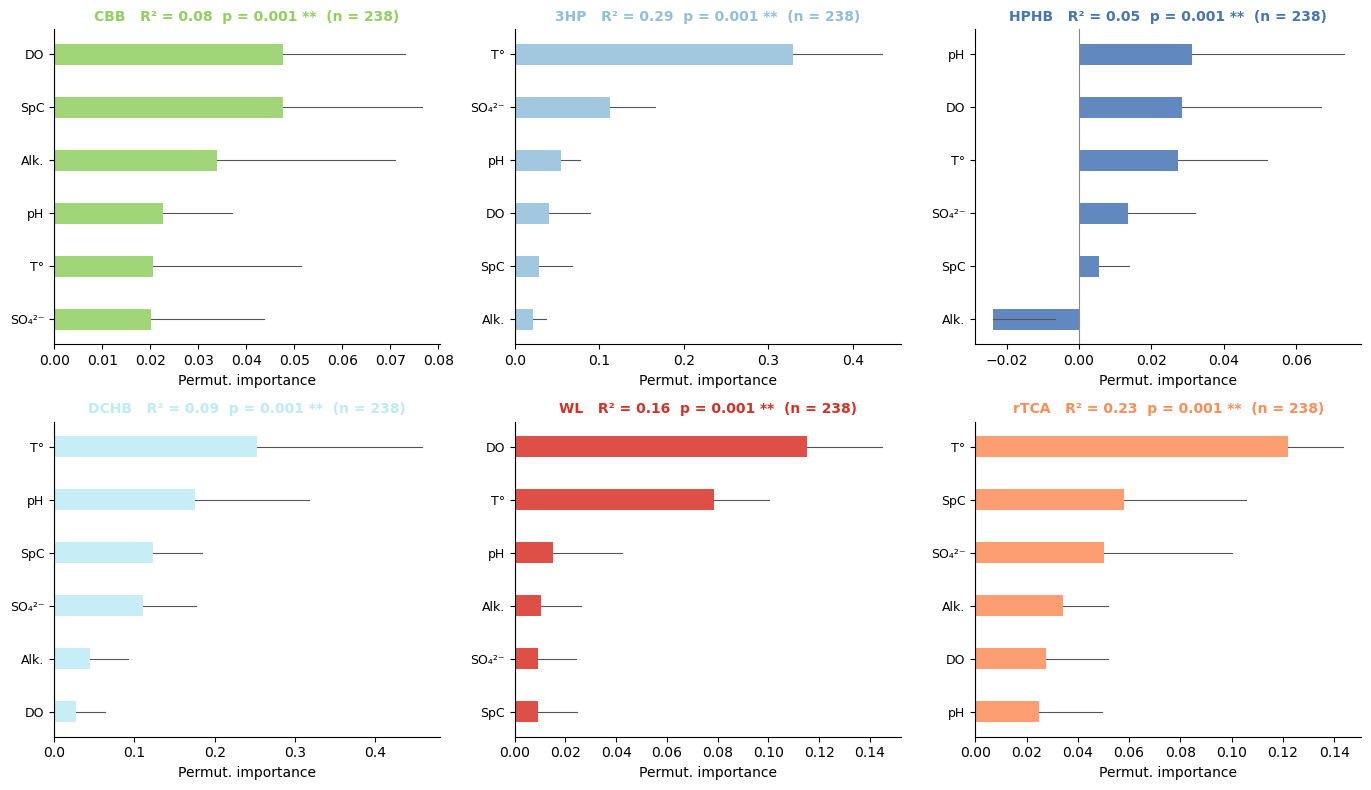

In [128]:
ENV_VARS = [
    ("temp",    "T°"),
    ("ph",      "pH"),
    ("do",      "DO"),
    ("spc",     "SpC"),
    ("so4",     "SO₄²⁻"),
    ("alk_tot", "Alk."),
]
LOG_VARS = {"spc", "so4", "alk_tot"}

env_pairs  = [(c, lbl) for c, lbl in ENV_VARS if c in sub.columns]
env_cols   = [c for c, _ in env_pairs]
var_labels = {c: lbl for c, lbl in env_pairs}

env_df = sub[env_cols].copy()
for col in env_cols:
    if col in LOG_VARS:
        env_df[col] = np.log10(env_df[col].clip(lower=1e-10))
        env_df[col] = env_df[col].replace([np.inf, -np.inf], np.nan)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf_results = {}

for pw in pathways:
    mask = sub[pw].notna()
    for col in env_cols:
        mask = mask & env_df[col].notna()
    X = env_df.loc[mask, env_cols].values
    y = sub.loc[mask, pw].values
    n = len(y)

    rf = RandomForestRegressor(n_estimators=300, max_features="sqrt",
                               min_samples_leaf=5, random_state=42, n_jobs=-1)
    score, _, p_value = permutation_test_score(
        rf, X, y, scoring="r2", cv=kf, n_permutations=999, random_state=42, n_jobs=-1)
    r2_cv = score

    perm_imps = np.zeros((len(env_cols), kf.get_n_splits()))
    for fi, (tr, te) in enumerate(kf.split(X)):
        rf_f = RandomForestRegressor(n_estimators=300, max_features="sqrt",
                                     min_samples_leaf=5, random_state=42, n_jobs=-1)
        rf_f.fit(X[tr], y[tr])
        pi = permutation_importance(rf_f, X[te], y[te], n_repeats=10,
                                    random_state=42, n_jobs=-1)
        perm_imps[:, fi] = pi.importances_mean

    imp_df = pd.DataFrame({
        "col":   env_cols,
        "label": [var_labels[v] for v in env_cols],
        "imp":   perm_imps.mean(axis=1),
        "std":   perm_imps.std(axis=1),
    }).sort_values("imp", ascending=False)

    rf_results[pw] = {"imp_df": imp_df, "r2_cv": r2_cv, "p_value": p_value, "n": n}
    sig = "**" if p_value < 0.01 else ("*" if p_value < 0.05 else "ns")
    print(f"{pw_names[pw]:6s}: n={n}  CV-R\u00b2={r2_cv:.3f}  p={p_value:.3f} {sig}  "
          f"top4={list(imp_df['label'].head(4))}")

# figure
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, pw in zip(axes, pathways):
    col = color_pathway[pw]
    imp_df = rf_results[pw]["imp_df"]
    r2_cv  = rf_results[pw]["r2_cv"]
    p_value = rf_results[pw]["p_value"]
    n      = rf_results[pw]["n"]

    y_pos = list(range(len(imp_df) - 1, -1, -1))
    ax.barh(y_pos, imp_df["imp"].values, color=col, alpha=0.85, height=0.4)
    for yp, iv, sv in zip(y_pos, imp_df["imp"].values, imp_df["std"].values):
        ax.plot([iv, iv + sv], [yp, yp], "-", color="#555555", lw=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(imp_df["label"].values, fontsize=9)
    ax.axvline(0, color="#888888", lw=0.8)
    ax.set_xlabel("Permut. importance", fontsize=10)
    sig_str = "**" if p_value < 0.01 else ("*" if p_value < 0.05 else "ns")
    ax.set_title(f"{pw_names[pw]}   R\u00b2 = {r2_cv:.2f}  p = {p_value:.3f} {sig_str}  (n = {n})",
                 fontsize=10, fontweight="bold", color=col)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
#plt.savefig("../outputs/RF_analysis.svg", format="svg", bbox_inches="tight")
plt.show()


Paper figure

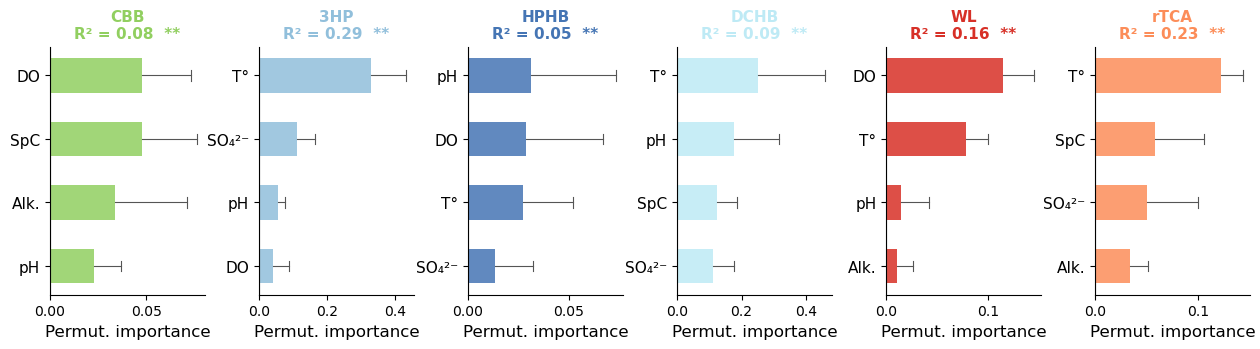

In [129]:
TOP_N = 4

fig, axes = plt.subplots(1, 6, figsize=(12.7, 3.6))

for ax, pw in zip(axes, pathways):
    col    = color_pathway[pw]
    imp_df = rf_results[pw]["imp_df"].head(TOP_N)
    r2_cv  = rf_results[pw]["r2_cv"]
    p_value = rf_results[pw]["p_value"]

    y_pos = list(range(TOP_N - 1, -1, -1))
    ax.barh(y_pos, imp_df["imp"].values, color=col, alpha=0.85, height=0.55)
    cap_h = 0.08
    for yp, iv, sv in zip(y_pos, imp_df["imp"].values, imp_df["std"].values):
        ax.plot([iv, iv + sv], [yp, yp], "-", color="#555555", lw=0.8)
        ax.plot([iv + sv, iv + sv], [yp - cap_h, yp + cap_h], "-", color="#555555", lw=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(imp_df["label"].values, fontsize=11)
    ax.axvline(0, color="#888888", lw=0.8)
    ax.set_xlabel("Permut. importance", fontsize=12)
    sig_str = "**" if p_value < 0.01 else ("*" if p_value < 0.05 else "ns")
    ax.set_title(f"{pw_names[pw]}\nR\u00b2 = {r2_cv:.2f}  {sig_str}",
                 fontsize=11, fontweight="bold", color=col)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(wspace=0.35)
plt.savefig("../outputs/rf_importance.svg", bbox_inches='tight', transparent=True)
plt.show()
